# Midterm Project
- AIGC 5500 0NA
- Advanced Deep Learning
- Summer 2026


### Team Info
HawkAI Detection | Group 1
| Name | Github |
| --- | --- |
| Kevin Joseff Cabrera (Kevin) | https://github.com/kjcabPL |
| Mohd Mujtaba Saighani (Mujtaba) | https://github.com/saigha1 |
| Thiago Segantini Nogeuira (Thiago) | https://github.com/thiaseg |
| Sayamon Sittiprom (Saya) | https://github.com/sittiprom |
| Yao-Fu Yang (Andy) | https://github.com/yaofu-yang |

### 1. Overview (Project Instructions)
In the activation functions and gradient descent module, you studied variations of gradient descent
and the hyperparameters that govern training dynamics. This project puts that knowledge to work:
you will systematically compare three modern optimizers on a real image-classification task, analyze
how each one behaves under different hyperparameter settings, and communicate your findings in a
live group presentation.
- Objective: Implement, tune, and compare Adam, RMSprop, and AdamW on a feedforward
neural network trained on the KMNIST dataset, and draw evidence-based conclusions about
their relative strengths and trade-offs.
- Importance: Choosing the wrong optimizer or leaving hyperparameters at default values is
one of the most common causes of poor model performance. This project builds the analytical
habits you will carry into every future deep learning task.

### 2. Dataset (Project Instructions)
Use the KMNIST (Kuzushiji-MNIST) dataset, available directly through PyTorch:
| Property | Details |
|---|---|
|Training Samples| 60,000 Images|
|Test Samples| 10,000 Images|
|Image Size | 28 x 28 Pixels, Greyscale|
|Classes| 10 (Japanese Hiragana Characters)|
|Complexity| Higher than MNIST; class boundaries overlap|


### Dependencies
1. optuna

In [24]:
# %pip install optuna
# %pip install plotly


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 8.4 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [plotly]2m1/2 [plotly]
Note: you may need to restart the kernel to use updated packages.


In [25]:
# Handle all imports first
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms

# Kuzushiji-MNIST Dataset
from torchvision.datasets import KMNIST
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import KFold
from typing import Type, Dict, Any, Callable
import numpy as np
from matplotlib import pyplot as plt
import time

import optuna
import optuna.visualization as vis
optuna.logging.set_verbosity(optuna.logging.WARNING)
import plotly

In [3]:
# Define data preparation constants
MANUAL_SEED = 498
ROOT ='./kuzushiji_data'

# Define architectural constants
INPUT_DIM = 784  # Cannot change
HIDDEN_DIM1 = 128  # Cannot change
HIDDEN_DIM2 = 64  # Cannot change
OUTPUT_DIM = 10  # Cannot change

# Define training/evaluation constants
EPOCHS = 20  # Min 20
BATCH_SIZE = 64  # May change
K_FOLD = 5 # Cannot change
TARGET_ACC = 0.6 # Will change
OPTUNA_TRIALS=5  # Adjustable

In [4]:
# Load the data and complete basic exploration

# Setting the random seed
torch.manual_seed(MANUAL_SEED)

# Check if GPU is available via Cuda or MPS (Mac)
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

# Load Training data as a single batch to compute mean and standard deviation
# Define a transformation to Tensor
transform = transforms.Compose([transforms.ToTensor()])
trainset = KMNIST(root=ROOT, train=True, download=True, transform=transform)
trainloader = DataLoader(trainset, batch_size=len(trainset), shuffle=True)
data = next(iter(trainloader))
mean = data[0].mean().item()
stddev = data[0].std().item()
print(f"The mean is : {mean}")
print(f"The standard deviation is: {stddev}")


Using device: mps
The mean is : 0.19176216423511505
The standard deviation is: 0.3483428359031677


In [5]:
# Check data shape
# (Batch Size, Channel Counts, Row Pixels, Column Pixels)
data[0].size()

torch.Size([60000, 1, 28, 28])

In [6]:
# Prepare the data

# Apply Input Standardization to reduce risk of saturating neurons
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize([mean], [stddev])])

# Create training and testing sets while applying standardization
trainset = KMNIST(root=ROOT, train=True, download=True, transform=transform)
testset = KMNIST(root=ROOT, train=False, download=True, transform=transform)


# Verify final dimension of all three data sets
print(f"Train set size: {len(trainset)}")
print(f"Test set size: {len(testset)}")

Train set size: 60000
Test set size: 10000


# 3. Model Architecture (Project Instructions)
Implement the following feedforward fully-connected architecture. Do not modify it; the architecture is fixed so that all differences between runs are attributable to the optimizer and its hyperparameters.

|Layer|Configuration|Notes
|---|---|---|
|Input|784 Neurons|Flatten 28x28 image|
|Hidden 1|128 Neurons, ReLU Activation||
|Hidden 1|64 Neurons, ReLU Activation||
|Output|10 Neurons, Softmax activation|One neuron per class|
|Loss function|Cross-Entropy Loss|Appropriate for multi-class classification|


In [7]:
# Define the forward pass. Final activation is omitted since softmax is part of
# cross-entropy loss function in PyTorch.
class FeedForwardNet(nn.Module):
    def __init__(
        self,
        input_dim:  int = INPUT_DIM,
        hidden_dim1: int = HIDDEN_DIM1,
        hidden_dim2: int = HIDDEN_DIM2,
        output_dim: int = OUTPUT_DIM
    ) -> None:
        super().__init__()
        # First Hidden Layer
        self.hidden1 = nn.Linear(input_dim, hidden_dim1)
        # Apply BatchNorm to first hidden layer
        self.batchNorm1 = nn.BatchNorm1d(num_features=hidden_dim1)
        # Apply random deactivation of neurons to reduce overfitting
        self.dropout1 = nn.Dropout(p=0.2)

        # Second Hidden Layer
        self.hidden2 = nn.Linear(hidden_dim1, hidden_dim2)
        # Apply BatchNorm to second hidden layer
        self.batchNorm2 = nn.BatchNorm1d(num_features=hidden_dim2)
        # Apply random deactivation of neurons to reduce overfitting
        self.dropout2 = nn.Dropout(p=0.2)

        # Final Output Layer
        self.output = nn.Linear(hidden_dim2, output_dim)

        # Customized function to initialize weights for each layer.
        self._initialize_weights()

    # Applies Weight Initialization technique.
    def _initialize_weights(self) -> None:
        # Kaiming (He) initialization for first hidden layer
        nn.init.kaiming_normal_(self.hidden1.weight, nonlinearity='relu')
        nn.init.constant_(self.hidden1.bias, 0.0)

        # Same for second hidden layer
        nn.init.kaiming_normal_(self.hidden2.weight, nonlinearity='relu')
        nn.init.constant_(self.hidden2.bias, 0.0)

        # Xavier (Glorot) initialization for the output layer (no activation).
        nn.init.xavier_uniform_(self.output.weight)
        nn.init.constant_(self.output.bias, 0.0)

    # Completes the forward pass
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Flatten the image from 28x28 to 784 pixels
        x = torch.flatten(x, start_dim=1)

        # First layers (hidden, batchnorm, relu activation, dropout)
        x = self.hidden1(x)
        x = self.batchNorm1(x)
        x = F.relu(x)
        x = self.dropout1(x)

        # Second Layers (hidden, batchnorm, relu activation, dropout)
        x = self.hidden2(x)
        x = self.batchNorm2(x)
        x = F.relu(x)
        x = self.dropout2(x)

        return self.output(x)    # Raw logits; softmax applied by loss function.

# Initializes the model.
model = FeedForwardNet()

# 4. Optimizers Under Investigation (Project Instructions)
You will train and evaluate the same fixed architecture using each of the three optimizers below. For 
every optimizer, perform a structured hyperparameter search (see Section 5) and report results for 
both the default configuration and the best configuration found. 
 
### 4.1  Adam (Adaptive Moment Estimation) 
- Key idea: Maintains separate adaptive learning rates for each parameter by combining first-
moment (momentum) and second-moment (uncentred variance) estimates. 
- Default settings: lr = 0.001, β1 = 0.9, β2 = 0.999, ε = 1e-8. 
- Investigate: The effect of learning rate and β1 on convergence speed and final accuracy. 
 
### 4.2  RMSprop (Root Mean Square Propagation) 
- Key idea: Divides the learning rate by a running average of the squared gradient magnitudes, 
preventing updates from growing too large. 
- Default settings: lr = 0.01, α = 0.99, ε = 1e-8. 
- Investigate: The effect of the decay factor α and learning rate on training stability. 
 
### 4.3  AdamW (Adam with Decoupled Weight Decay) 
- Key  idea:  Corrects a known flaw in Adam’s L2 regularization by decoupling weight decay 
from the adaptive learning-rate update, leading to better generalization. 
- Default settings: lr = 0.001, β1 = 0.9, β2 = 0.999, ε = 1e-8, weight_decay = 0.01. 
- Investigate: The effect of weight_decay and learning rate on the gap between training and 
test accuracy. 

### Branch TODO 1: Research the Assigned Optimizer
The project instructions give a brief overview of the key ideas, default settings, and investigation pathways for each optimizer. Start by completing the investigation tasks but go deeper to find other intereting and unique parameters/features of each optimizer (including ones not covered in lecture).

Action Item: Add a document in the branch with the findings, or include the findings directly in the notebook. For reference, the final PDF report requires the following: "Optimizer descriptions and theoretical background"

### Adam (Adaptive Moment Estimation) — Research Findings

**Key Idea:**
Adam (Kingma & Ba, 2015) combines two well-known optimization techniques: momentum and RMSprop. It maintains two running averages for each parameter — the first moment (mean of gradients, like momentum) and the second moment (mean of squared gradients, like RMSprop). This allows Adam to compute an adaptive learning rate for each individual parameter, making it well-suited for problems with sparse gradients or noisy data.

**Default Parameters:**
- `lr = 0.001` — the global learning rate (step size)
- `β1 = 0.9` — decay rate for the first moment (momentum). Controls how much past gradients influence the current update.
- `β2 = 0.999` — decay rate for the second moment. Controls how much past squared gradients influence the scaling.
- `ε = 1e-8` — small constant to prevent division by zero.

**Additional Features (beyond lecture):**
- Adam includes **bias correction** in the first few iterations, which prevents the moment estimates from being too small at the start of training.
- The `weight_decay` parameter can be added to Adam, but it is applied in a coupled way (unlike AdamW, which decouples it). This is a known limitation of Adam's L2 regularization.
- Adam is generally robust to the choice of learning rate compared to SGD, but it can sometimes converge to sharp minima that generalize less well.

**Investigation Plan:**
I will investigate the effect of `lr` and `β1` on convergence speed and final accuracy by testing four configurations:
- Config 1 (default): `lr=0.001`, `β1=0.9`
- Config 2 (higher lr): `lr=0.01`, `β1=0.9`
- Config 3 (lower lr): `lr=0.0001`, `β1=0.9`
- Config 4 (lower β1): `lr=0.001`, `β1=0.8`


# Methodology (Project Instructions)
### 5.1  Hyperparameter Search 
For each optimizer, evaluate at least four (4) distinct hyperparameter configurations. You may use 
grid search, random search, or a manual systematic approach. Document your search strategy and 
justify your final selection. 
 
At minimum, vary the following for each optimizer: 
- Learning  rate: try values  spanning  at  least  two  orders  of magnitude (e.g.,  0.1,  0.01,  0.001, 
0.0001). 
- At least one optimizer-specific hyperparameter (e.g., β1 for Adam/AdamW, decay factor for 
RMSprop).

### 5.2  Cross-Validation 
- Apply 5-fold cross-validation on the training set to estimate generalization performance. 
- Report  the  mean  and  standard  deviation  of  validation  accuracy  across  folds  for  each 
configuration. 
- Use the best configuration identified through cross-validation to train a final model on the full 
training set.

### 5.3  Training Protocol 
- Train  for  a  fixed  number  of  epochs  (minimum  20)  across  all  configurations  to  ensure  fair 
comparison. 
- Use the same random seed for all runs to control for initialization variance. 
- Record training loss, validation loss, and validation accuracy at each epoch. 
- Evaluate the final model on the held-out test set; report test accuracy and test loss.

### 5.4  Metrics to Record
|Metric|Description|
|---|---|
|Training Accuracy|Accuracy on the training set at the final epoch|
|Validation Accuracy|Mean cross-validation accuracy (and std dev) across 5 folds|
|Test Accuracy|Accuracy on the held-out test set |
|Final Loss|Training and test loss at the end of training|
|Convergence Speed|Number of epochs to reach a target validation accuracy (e.g., 
80%)|
|Training Time|Wall-clock time for a full training run|

In [8]:
# Define a reusable run Epoch function for both training & evaluation loops
def run_epoch(
    model:     nn.Module,
    loader:    DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer | None,
    device:    torch.device,
    training:  bool,
) -> tuple[float, float]:
    """Run one full pass over the DataLoader.
    Pass optimizer=None during evaluation.
    Returns (mean loss, accuracy).
    """
    model.train() if training else model.eval()

    total_loss    = 0.0
    total_correct = 0
    total_samples = 0

    # No gradient/back propagation if in evaluation mode.
    context = torch.enable_grad() if training else torch.no_grad()

    with context:
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)

            outputs = model(inputs)
            # Cross-entropy loss does not need one-hot targets in PyTorch.
            loss = criterion(outputs, targets)

            # Only run for training mode. Evaluation mode skips this.
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            # Accumulate metrics.
            _, predicted   = torch.max(outputs, dim=1)
            total_correct += (predicted == targets).sum().item()
            total_samples += targets.size(0)
            total_loss    += loss.item()

    return total_loss / len(loader), total_correct / total_samples

In [9]:
# Define a reusable k-fold cross-validation function for different optimizers
# Handles the requirements in 5.2 Cross Validation & 5.3 Training Protocol

def cross_validate_config(
    model_class: Callable[[], nn.Module],  # Need a fresh model for each fold
    train_dataset: Any,
    optimizer_class: Type[torch.optim.Optimizer],  # Type of optimizer
    optimizer_kwargs: Dict[str, Any],  # Hyperparameters
    criterion: nn.Module,
    device: torch.device,
    epochs: int = EPOCHS,  # 5.3 Req, min 20 Epochs
    batch_size: int = BATCH_SIZE,
    n_splits: int = K_FOLD,  # 5.2 Req: 5-fold
    random_seed: int = MANUAL_SEED,

) -> tuple[float, float]:
    """
    Performs K-Fold Cross-Validation for a given model, optimizer, and hyperparameter configuration.
    
    Returns:
        dictionary: {
        "mean_accuracy", --> Represents mean validation accuracy 
        "std_accuracy", --> Represents standard deviation of validaion accuracy
        }
    """
    k_fold = KFold(n_splits=n_splits, shuffle=True, random_state=random_seed)
    fold_best_accuracies = []
    
    for fold, (train_idx, val_idx) in enumerate(k_fold.split(train_dataset)):
        # 5.3 Req: Use the same random seed for all runs to control for initialization variance.
        torch.manual_seed(random_seed)
        
        # Move model to device
        model = model_class().to(device)
        
        # Create optimizer using the class and parameter arguments
        optimizer = optimizer_class(model.parameters(), **optimizer_kwargs)
        
        # Generate the training folds and validation fold
        train_sub = Subset(train_dataset, train_idx)
        val_sub   = Subset(train_dataset, val_idx)
        
        # Generate the training and validation loaders
        trainloader = DataLoader(train_sub, batch_size=batch_size, shuffle=True)
        valloader   = DataLoader(val_sub, batch_size=batch_size, shuffle=False)
        
        # For tracking accuracy
        best_fold_val_acc = 0.0
        
        # Complete the training and validation per Epoch and capture metrics
        for epoch in range(epochs):
            # Training loop with the training loss and training accuracy
            train_loss, train_acc = run_epoch(
                model, trainloader, criterion, optimizer, device, training=True
            )

            # Validation loop with the validation loss and validation accuracy
            # No optimizers needed for validation, training pathway should not be run
            val_loss, val_acc = run_epoch(
                model, valloader, criterion, optimizer=None, device=device, training=False
            )
            
            # Update the best validation accuracy
            if val_acc > best_fold_val_acc:
                best_fold_val_acc = val_acc

            # Report Epoch & Losses/Accuracies
            print(f"Fold {fold + 1}/{n_splits} Epoch {epoch + 1}/{epochs} | Training Accuracy: {(train_acc * 100):.2f}% | Validation Accuracy: {(val_acc * 100):.2f}%")
        
        # Tracking validation accuracies
        fold_best_accuracies.append(best_fold_val_acc)
        print(f"    Fold {fold + 1} Best Val Acc: {best_fold_val_acc:.4f}")
        
    # Calculate aggregated statistics
    acc_tensor = torch.tensor(fold_best_accuracies)

    # 5.2 Req: report mean and standard deviation of validation accuracies
    # Needed for 6.2 plotting accuracy distribution as well.
    return acc_tensor.mean().item(), acc_tensor.std().item()



In [10]:
# Define a function to handle different GPU.
def synchronize_device(device):
    """Synchronizes the device if it supports it."""
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        # MPS currently doesn't have a direct equivalent to cuda.synchronize() 
        # that is required for standard timing, as it is often handled implicitly
        # or via different backend calls.
        pass

In [11]:
# Define a reusable function to run the HPO for different optimizers.
def run_optimizer_trials(optimizer_name, optimizer_class, hyperparameter_list, results_storage):
    """
    Performs hyperparameter tuning for a specific optimizer and 
    updates the shared results_storage dictionary.
    """
    # Initialize the dictionary for this optimizer if it doesn't exist
    if optimizer_name not in results_storage:
        results_storage[optimizer_name] = {
            "best_score": -1.0,
            "best_data": None,
            "best_params": None
        }

    # Iterate through pre-defined configurations
    for config_idx, config_kwargs in enumerate(hyperparameter_list):
        print(f"Testing {optimizer_name} config {config_idx + 1}/{len(hyperparameter_list)}: {config_kwargs}")

        # Invoke the Cross-Validation function
        result = cross_validate_config(
            model_class=FeedForwardNet,
            train_dataset=trainset,
            optimizer_class=optimizer_class,
            optimizer_kwargs=config_kwargs,
            criterion=nn.CrossEntropyLoss(),
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            device=device
        )

        # Update storage with best config
        if result[0] > results_storage[optimizer_name]["best_score"]:
            results_storage[optimizer_name]["best_score"] = result[0]
            results_storage[optimizer_name]["best_data"] = result
            results_storage[optimizer_name]["best_params"] = config_kwargs
            
    print(f"Best config for {optimizer_name}: {results_storage[optimizer_name]['best_params']}")
    print(f"Mean Validation Accuracy: {results_storage[optimizer_name]['best_score']:.4f}\n")

In [12]:
# Reusable final model training and evaluation function
def train_and_evaluate_model(optimizer_name, optimizer_class, results_storage):
    """
    Performs final training and evaluation based on the best configurations
    for the specified optimizer.
    """
    # Initialize/Reset the metrics entry for this optimizer
    results_storage[optimizer_name]["training_metrics"] = {
        "train_losses": [],
        "train_accuracies": [],
        "test_losses": [],
        "test_accuracies": [],
        "convergence_epoch": None,
        "total_training_time": 0.0
    }
    metrics = results_storage[optimizer_name]["training_metrics"]

    # Refresh seeding and model
    torch.manual_seed(MANUAL_SEED)
    final_model = FeedForwardNet().to(device)

    # Access best params and initialize optimizer
    best_params = results_storage[optimizer_name]["best_params"]
    final_optimizer = optimizer_class(final_model.parameters(), **best_params)
    loss_function = torch.nn.CrossEntropyLoss()

    # Data Loaders
    full_train_loader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True)
    testloader = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False)

    # Sync and record start time
    synchronize_device(device)
    start_time = time.perf_counter()

    for epoch in range(EPOCHS):
        train_loss, train_acc = run_epoch(
            final_model, full_train_loader, loss_function, final_optimizer, device, training=True
        )
        test_loss, test_acc = run_epoch(
            final_model, testloader, loss_function, optimizer=None, device=device, training=False
        )

        # Store metrics
        metrics["train_losses"].append(train_loss)
        metrics["train_accuracies"].append(train_acc)
        metrics["test_losses"].append(test_loss)
        metrics["test_accuracies"].append(test_acc)
        
        # Identify Convergence Epoch
        if test_acc >= TARGET_ACC and metrics["convergence_epoch"] is None:
            metrics["convergence_epoch"] = epoch + 1
            
        print(f"[{optimizer_name}] Epoch {epoch + 1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Test Acc: {test_acc:.4f}")

    # Sync and record total time
    synchronize_device(device)
    metrics["total_training_time"] = time.perf_counter() - start_time
    print(f"Total Training time: {metrics['total_training_time']}")


    # Handle default convergence
    if metrics["convergence_epoch"] is None:
        metrics["convergence_epoch"] = EPOCHS
        
    return metrics

In [13]:
# Runa all trials
# Define your optimizer trials
trials = [
    {
        "name": "Adam",
        "class": torch.optim.Adam,
        "configs": [
            {"lr": 0.001, "betas": (0.9, 0.999), "weight_decay": 1e-4},    # Config 1 — baseline
            {"lr": 0.01,  "betas": (0.9, 0.999), "weight_decay": 1e-4},    # Config 2 — higher learning rate
            {"lr": 0.001,  "betas": (0.9, 0.999), "weight_decay": 1e-3},    # Config 3 — higher decay
            {"lr": 0.001,"betas": (0.9, 0.9), "weight_decay": 1e-4},     # Config 4 — lower beta2

            # Other trials completed that will be included in discussion.
            # {"lr": 0.001, "betas": (0.9, 0.999)},
            # {"lr": 0.01,  "betas": (0.9, 0.999)},
            # {"lr": 0.0001,"betas": (0.9, 0.999)},
            # {"lr": 0.001, "betas": (0.8, 0.999)},
            # {"lr": 0.001, "weight_decay": 1e-4},
            # {"lr": 0.01,  "weight_decay": 1e-3},
            # {"lr": 0.001, "weight_decay": 0.0},
            # {"lr": 0.001, "weight_decay": 1e-2},
            # {"lr": 0.001, "betas": (0.8, 0.999), "weight_decay": 1e-2},
        ]
    },
    {
        "name": "AdamW",
        "class": torch.optim.AdamW,
        "configs": [
            {"lr": 0.001,  "weight_decay": 0.01},  # Baseline comparison
            {"lr": 0.01,   "weight_decay": 0.01},  # Higher learning rate
            {"lr": 0.0001, "weight_decay": 0.1},  # Lower learning rate
            {"lr": 0.001,   "weight_decay": 0.1},  # Higher weight decay
            {"lr": 0.001, "weight_decay": 0.001},  # Lower weight_decay
        ]
    },

    {
        "name": "RMSprop",
        "class": torch.optim.RMSprop,
        "configs": [
            {"lr": 0.01,   "alpha": 0.99, "eps": 1e-8}, # Baseline comparison                         
            {"lr": 0.01,   "alpha": 0.99, "eps": 1e-8, "momentum": 0.9}, # Add momentum        
            {"lr": 0.01,   "alpha": 0.80, "eps": 1e-8}, # Decrease alpha                        
            {"lr": 0.001,  "alpha": 0.99, "eps": 1e-8}, # Decrease learning rate
            {"lr": 0.01,   "alpha": 0.99, "eps": 1e-8, "weight_decay": 1e-3}, # Add weight_decay      

            # Other Trials that were completed and will be included in discussion
            # {"lr": 0.01,   "alpha": 0.99,  "eps": 1e-07, "momentum":  0.003},
            # {"lr": 0.0001, "alpha": 0.99, "eps": 1e-8},  
            # {"lr": 0.01,   "alpha": 0.99, "eps": 1e-8, "weight_decay": 1e-4},
            # {"lr": 0.01,   "alpha": 0.99, "eps": 1e-8, "weight_decay": 1e-2},   
            # {"lr" :0.01, "alpha" : 0.99, "eps" :1e-8},
            # {"lr": 0.01,   "alpha": 0.99, "eps": 1e-8, "momentum":  0.9},
            # {"lr": 0.01,   "alpha": 0.99, "eps": 1e-8, "momentum":  0.001},
            # {"lr": 0.01,   "alpha": 0.99, "eps": 1e-8, "momentum":  0.003},
            # {"lr": 0.01,   "alpha": 0.80, "eps": 1e-8, "momentum":  0.003},
            # {"lr": 0.01,   "alpha": 0.99,  "eps": 1e-07, "momentum":  0.003},
            # {"lr": 0.001,   "alpha": 0.99, "eps": 1e-8, "momentum":  0.003 ,},
            # {"lr": 0.0001,   "alpha": 0.99, "eps": 1e-8, "momentum":  0.003,"weight_decay": 1e-2}
        ]
    }
]

# Run all trials
results_storage = {}
for trial in trials:
    run_optimizer_trials(
        trial["name"], 
        trial["class"], 
        trial["configs"], 
        results_storage
    )

Testing Adam config 1/4: {'lr': 0.001, 'betas': (0.9, 0.999), 'weight_decay': 0.0001}
Fold 1/5 Epoch 1/20 | Training Accuracy: 80.30% | Validation Accuracy: 90.43%
Fold 1/5 Epoch 2/20 | Training Accuracy: 88.30% | Validation Accuracy: 92.53%
Fold 1/5 Epoch 3/20 | Training Accuracy: 90.31% | Validation Accuracy: 93.49%
Fold 1/5 Epoch 4/20 | Training Accuracy: 91.55% | Validation Accuracy: 93.92%
Fold 1/5 Epoch 5/20 | Training Accuracy: 92.42% | Validation Accuracy: 94.24%
Fold 1/5 Epoch 6/20 | Training Accuracy: 92.84% | Validation Accuracy: 94.41%
Fold 1/5 Epoch 7/20 | Training Accuracy: 93.33% | Validation Accuracy: 94.58%
Fold 1/5 Epoch 8/20 | Training Accuracy: 93.73% | Validation Accuracy: 94.81%
Fold 1/5 Epoch 9/20 | Training Accuracy: 94.05% | Validation Accuracy: 94.90%
Fold 1/5 Epoch 10/20 | Training Accuracy: 94.46% | Validation Accuracy: 95.00%
Fold 1/5 Epoch 11/20 | Training Accuracy: 94.40% | Validation Accuracy: 95.13%
Fold 1/5 Epoch 12/20 | Training Accuracy: 94.80% | Val

In [14]:
# Additional HPO using optuna
storage_key = "RMSprop_optuna"
optimizer_name = "RMSprop"
optimizer_class = torch.optim.RMSprop

# Ensure the storage entry exists
results_storage[storage_key] = {
    "best_score": -1.0,
    "best_data": None,
    "best_params": None
}

def objective(trial):
    # Optuna suggests hyperparameters
    config_kwargs = {
        "lr":           trial.suggest_float("lr",           1e-5, 1e-1, log=True),
        "alpha":        trial.suggest_float("alpha",        0.8,  0.99),
        "eps":          trial.suggest_float("eps",          1e-9, 1e-6, log=True),
        "momentum":     trial.suggest_float("momentum",     0.0,  0.9),
        "weight_decay": trial.suggest_float("weight_decay", 1e-5, 1e-2, log=True),
    }

    # Print the current configuration being assessed
    print(f"[{optimizer_name}] Testing trial {trial.number + 1}/{OPTUNA_TRIALS}: {config_kwargs}")

    result = cross_validate_config(
        model_class=FeedForwardNet,
        train_dataset=trainset,
        optimizer_class=optimizer_class,
        optimizer_kwargs=config_kwargs,
        criterion=nn.CrossEntropyLoss(),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        device=device
    )

    # Check and update results_storage
    if result[0] > results_storage[storage_key]["best_score"]:
        results_storage[storage_key]["best_score"] = result[0]
        results_storage[storage_key]["best_data"] = result
        results_storage[storage_key]["best_params"] = config_kwargs

    return result[0]  # Return mean validation accuracy

# Run the study
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=MANUAL_SEED)
)
study.optimize(objective, n_trials=OPTUNA_TRIALS, show_progress_bar=True)

# Final Reporting
print(f"\nBest configuration for {optimizer_name}: {results_storage[storage_key]['best_params']}")
print(f"Mean Validation Accuracy: {results_storage[storage_key]['best_score']:.4f}")

  0%|          | 0/5 [00:00<?, ?it/s]

[RMSprop] Testing trial 1/5: {'lr': 6.858271194590212e-05, 'alpha': 0.8158799881493717, 'eps': 5.771925436866321e-08, 'momentum': 0.6036621990156602, 'weight_decay': 0.0004334966263623137}
Fold 1/5 Epoch 1/20 | Training Accuracy: 67.49% | Validation Accuracy: 84.06%
Fold 1/5 Epoch 2/20 | Training Accuracy: 82.02% | Validation Accuracy: 87.39%
Fold 1/5 Epoch 3/20 | Training Accuracy: 84.88% | Validation Accuracy: 89.09%
Fold 1/5 Epoch 4/20 | Training Accuracy: 86.83% | Validation Accuracy: 90.40%
Fold 1/5 Epoch 5/20 | Training Accuracy: 87.92% | Validation Accuracy: 90.93%
Fold 1/5 Epoch 6/20 | Training Accuracy: 88.78% | Validation Accuracy: 91.82%
Fold 1/5 Epoch 7/20 | Training Accuracy: 89.69% | Validation Accuracy: 92.19%
Fold 1/5 Epoch 8/20 | Training Accuracy: 90.10% | Validation Accuracy: 92.68%
Fold 1/5 Epoch 9/20 | Training Accuracy: 90.52% | Validation Accuracy: 92.89%
Fold 1/5 Epoch 10/20 | Training Accuracy: 91.01% | Validation Accuracy: 93.13%
Fold 1/5 Epoch 11/20 | Trainin

Best trial: 0. Best value: 0.946133:  20%|██        | 1/5 [17:24<1:09:36, 1044.24s/it]

Fold 5/5 Epoch 20/20 | Training Accuracy: 93.24% | Validation Accuracy: 94.45%
    Fold 5 Best Val Acc: 0.9449
[RMSprop] Testing trial 2/5: {'lr': 0.05993920827308765, 'alpha': 0.856094388775184, 'eps': 1.093658522207711e-08, 'momentum': 0.38925497119038166, 'weight_decay': 0.0004133923207082161}
Fold 1/5 Epoch 1/20 | Training Accuracy: 62.35% | Validation Accuracy: 68.02%
Fold 1/5 Epoch 2/20 | Training Accuracy: 63.05% | Validation Accuracy: 68.72%
Fold 1/5 Epoch 3/20 | Training Accuracy: 63.31% | Validation Accuracy: 69.90%
Fold 1/5 Epoch 4/20 | Training Accuracy: 63.06% | Validation Accuracy: 65.35%
Fold 1/5 Epoch 5/20 | Training Accuracy: 63.18% | Validation Accuracy: 71.52%
Fold 1/5 Epoch 6/20 | Training Accuracy: 63.40% | Validation Accuracy: 63.51%
Fold 1/5 Epoch 7/20 | Training Accuracy: 63.31% | Validation Accuracy: 68.14%
Fold 1/5 Epoch 8/20 | Training Accuracy: 62.91% | Validation Accuracy: 70.16%
Fold 1/5 Epoch 9/20 | Training Accuracy: 62.90% | Validation Accuracy: 68.16%


Best trial: 0. Best value: 0.946133:  40%|████      | 2/5 [34:57<52:28, 1049.59s/it]  

...

Fold 5/5 Epoch 20/20 | Training Accuracy: 89.97% | Validation Accuracy: 92.99%
    Fold 5 Best Val Acc: 0.9343
[RMSprop] Testing trial 4/5: {'lr': 1.6814261149043273e-05, 'alpha': 0.8820601368097155, 'eps': 5.216097003030598e-07, 'momentum': 0.22362441628737495, 'weight_decay': 0.0026094605497931213}
Fold 1/5 Epoch 1/20 | Training Accuracy: 31.28% | Validation Accuracy: 63.19%
Fold 1/5 Epoch 2/20 | Training Accuracy: 59.28% | Validation Accuracy: 73.74%
Fold 1/5 Epoch 3/20 | Training Accuracy: 68.43% | Validation Accuracy: 77.58%
Fold 1/5 Epoch 4/20 | Training Accuracy: 72.75% | Validation Accuracy: 79.92%
Fold 1/5 Epoch 5/20 | Training Accuracy: 75.55% | Validation Accuracy: 81.47%
Fold 1/5 Epoch 6/20 | Training Accuracy: 77.26% | Validation Accuracy: 82.73%
Fold 1/5 Epoch 7/20 | Training Accuracy: 78.74% | Validation Accuracy: 83.59%
Fold 1/5 Epoch 8/20 | Training Accuracy: 79.98% | Validation Accuracy: 84.44%
Fold 1/5 Epoch 9/20 | Training Accuracy: 80.74% | Validation Accuracy: 85.

Best trial: 0. Best value: 0.946133:  80%|████████  | 4/5 [1:10:07<17:31, 1051.64s/it]

Fold 5/5 Epoch 20/20 | Training Accuracy: 85.59% | Validation Accuracy: 89.31%
    Fold 5 Best Val Acc: 0.8931
[RMSprop] Testing trial 5/5: {'lr': 0.000550157543251305, 'alpha': 0.9087308473429094, 'eps': 5.61294331594571e-07, 'momentum': 0.2853443059549671, 'weight_decay': 0.00707466643351557}
Fold 1/5 Epoch 1/20 | Training Accuracy: 80.27% | Validation Accuracy: 89.73%
Fold 1/5 Epoch 2/20 | Training Accuracy: 87.73% | Validation Accuracy: 91.19%
Fold 1/5 Epoch 3/20 | Training Accuracy: 89.51% | Validation Accuracy: 92.53%
Fold 1/5 Epoch 4/20 | Training Accuracy: 90.28% | Validation Accuracy: 93.07%
Fold 1/5 Epoch 5/20 | Training Accuracy: 90.63% | Validation Accuracy: 93.18%
Fold 1/5 Epoch 6/20 | Training Accuracy: 90.81% | Validation Accuracy: 93.47%
Fold 1/5 Epoch 7/20 | Training Accuracy: 91.14% | Validation Accuracy: 92.92%
Fold 1/5 Epoch 8/20 | Training Accuracy: 91.15% | Validation Accuracy: 93.47%
Fold 1/5 Epoch 9/20 | Training Accuracy: 91.12% | Validation Accuracy: 93.42%
Fo

Best trial: 0. Best value: 0.946133: 100%|██████████| 5/5 [1:27:29<00:00, 1049.97s/it]

Fold 5/5 Epoch 20/20 | Training Accuracy: 91.53% | Validation Accuracy: 94.06%
    Fold 5 Best Val Acc: 0.9416

Best configuration for RMSprop: {'lr': 6.858271194590212e-05, 'alpha': 0.8158799881493717, 'eps': 5.771925436866321e-08, 'momentum': 0.6036621990156602, 'weight_decay': 0.0004334966263623137}
Mean Validation Accuracy: 0.9461


In [15]:
print(storage_key)

RMSprop_optuna


In [16]:
# Adam through manual HPO
adam_metrics = train_and_evaluate_model(
    "Adam", torch.optim.Adam, results_storage
)

[Adam] Epoch 1/20 | Train Loss: 0.6083 | Test Acc: 0.8140
[Adam] Epoch 2/20 | Train Loss: 0.3592 | Test Acc: 0.8500
[Adam] Epoch 3/20 | Train Loss: 0.2948 | Test Acc: 0.8595
[Adam] Epoch 4/20 | Train Loss: 0.2594 | Test Acc: 0.8747
[Adam] Epoch 5/20 | Train Loss: 0.2356 | Test Acc: 0.8775
[Adam] Epoch 6/20 | Train Loss: 0.2155 | Test Acc: 0.8819
[Adam] Epoch 7/20 | Train Loss: 0.2049 | Test Acc: 0.8760
[Adam] Epoch 8/20 | Train Loss: 0.1942 | Test Acc: 0.8899
[Adam] Epoch 9/20 | Train Loss: 0.1852 | Test Acc: 0.8854
[Adam] Epoch 10/20 | Train Loss: 0.1786 | Test Acc: 0.8871
[Adam] Epoch 11/20 | Train Loss: 0.1754 | Test Acc: 0.8883
[Adam] Epoch 12/20 | Train Loss: 0.1697 | Test Acc: 0.8910
[Adam] Epoch 13/20 | Train Loss: 0.1655 | Test Acc: 0.8904
[Adam] Epoch 14/20 | Train Loss: 0.1593 | Test Acc: 0.8905
[Adam] Epoch 15/20 | Train Loss: 0.1562 | Test Acc: 0.8906
[Adam] Epoch 16/20 | Train Loss: 0.1517 | Test Acc: 0.8954
[Adam] Epoch 17/20 | Train Loss: 0.1525 | Test Acc: 0.8890
[Adam]

In [17]:
# AdamW through manual HPO
adamw_metrics = train_and_evaluate_model(
    "AdamW", torch.optim.AdamW, results_storage
)

[AdamW] Epoch 1/20 | Train Loss: 0.6080 | Test Acc: 0.8132
[AdamW] Epoch 2/20 | Train Loss: 0.3574 | Test Acc: 0.8491
[AdamW] Epoch 3/20 | Train Loss: 0.2944 | Test Acc: 0.8601
[AdamW] Epoch 4/20 | Train Loss: 0.2575 | Test Acc: 0.8714
[AdamW] Epoch 5/20 | Train Loss: 0.2342 | Test Acc: 0.8778
[AdamW] Epoch 6/20 | Train Loss: 0.2126 | Test Acc: 0.8820
[AdamW] Epoch 7/20 | Train Loss: 0.2014 | Test Acc: 0.8798
[AdamW] Epoch 8/20 | Train Loss: 0.1880 | Test Acc: 0.8945
[AdamW] Epoch 9/20 | Train Loss: 0.1806 | Test Acc: 0.8871
[AdamW] Epoch 10/20 | Train Loss: 0.1740 | Test Acc: 0.8899
[AdamW] Epoch 11/20 | Train Loss: 0.1687 | Test Acc: 0.8908
[AdamW] Epoch 12/20 | Train Loss: 0.1618 | Test Acc: 0.8952
[AdamW] Epoch 13/20 | Train Loss: 0.1578 | Test Acc: 0.8968
[AdamW] Epoch 14/20 | Train Loss: 0.1507 | Test Acc: 0.8905
[AdamW] Epoch 15/20 | Train Loss: 0.1457 | Test Acc: 0.8932
[AdamW] Epoch 16/20 | Train Loss: 0.1427 | Test Acc: 0.8971
[AdamW] Epoch 17/20 | Train Loss: 0.1379 | Test A

In [18]:
# RMSprop through manual HPO
rmsprop_metrics = train_and_evaluate_model(
    "RMSprop", torch.optim.RMSprop, results_storage
)

[RMSprop] Epoch 1/20 | Train Loss: 0.4779 | Test Acc: 0.8300
[RMSprop] Epoch 2/20 | Train Loss: 0.3183 | Test Acc: 0.8642
[RMSprop] Epoch 3/20 | Train Loss: 0.2685 | Test Acc: 0.8694
[RMSprop] Epoch 4/20 | Train Loss: 0.2486 | Test Acc: 0.8734
[RMSprop] Epoch 5/20 | Train Loss: 0.2311 | Test Acc: 0.8864
[RMSprop] Epoch 6/20 | Train Loss: 0.2123 | Test Acc: 0.8768
[RMSprop] Epoch 7/20 | Train Loss: 0.2081 | Test Acc: 0.8926
[RMSprop] Epoch 8/20 | Train Loss: 0.2003 | Test Acc: 0.8892
[RMSprop] Epoch 9/20 | Train Loss: 0.1891 | Test Acc: 0.8878
[RMSprop] Epoch 10/20 | Train Loss: 0.1807 | Test Acc: 0.8942
[RMSprop] Epoch 11/20 | Train Loss: 0.1763 | Test Acc: 0.8856
[RMSprop] Epoch 12/20 | Train Loss: 0.1694 | Test Acc: 0.8944
[RMSprop] Epoch 13/20 | Train Loss: 0.1672 | Test Acc: 0.8994
[RMSprop] Epoch 14/20 | Train Loss: 0.1639 | Test Acc: 0.8948
[RMSprop] Epoch 15/20 | Train Loss: 0.1572 | Test Acc: 0.8938
[RMSprop] Epoch 16/20 | Train Loss: 0.1518 | Test Acc: 0.8974
[RMSprop] Epoch 1

In [19]:
# RMSprop through Optuna
rmsprop_optuna_metrics = train_and_evaluate_model(
    "RMSprop_optuna", torch.optim.RMSprop, results_storage
)

[RMSprop_optuna] Epoch 1/20 | Train Loss: 1.0083 | Test Acc: 0.7112
[RMSprop_optuna] Epoch 2/20 | Train Loss: 0.5693 | Test Acc: 0.7686
[RMSprop_optuna] Epoch 3/20 | Train Loss: 0.4705 | Test Acc: 0.7930
[RMSprop_optuna] Epoch 4/20 | Train Loss: 0.4106 | Test Acc: 0.8170
[RMSprop_optuna] Epoch 5/20 | Train Loss: 0.3722 | Test Acc: 0.8278
[RMSprop_optuna] Epoch 6/20 | Train Loss: 0.3440 | Test Acc: 0.8420
[RMSprop_optuna] Epoch 7/20 | Train Loss: 0.3233 | Test Acc: 0.8404
[RMSprop_optuna] Epoch 8/20 | Train Loss: 0.3074 | Test Acc: 0.8540
[RMSprop_optuna] Epoch 9/20 | Train Loss: 0.2892 | Test Acc: 0.8539
[RMSprop_optuna] Epoch 10/20 | Train Loss: 0.2789 | Test Acc: 0.8568
[RMSprop_optuna] Epoch 11/20 | Train Loss: 0.2697 | Test Acc: 0.8642
[RMSprop_optuna] Epoch 12/20 | Train Loss: 0.2612 | Test Acc: 0.8656
[RMSprop_optuna] Epoch 13/20 | Train Loss: 0.2532 | Test Acc: 0.8709
[RMSprop_optuna] Epoch 14/20 | Train Loss: 0.2421 | Test Acc: 0.8640
[RMSprop_optuna] Epoch 15/20 | Train Loss: 

# 6. Results 
### 6.1  Summary Table 
Present a table comparing the best configuration of each optimizer across all metrics defined in Section 5.4. Include both default and best configurations for each optimizer. 
 
### 6.2  Required Plots 
- Training and validation loss curves over epochs for the best configuration of each optimizer 
(all three on one plot for direct comparison). 
- Training and validation accuracy curves over epochs. 
- Bar chart comparing final test accuracy across optimizers. 
- Box plot or error-bar plot showing the cross-validation accuracy distribution for each optimizer. 
- Optional: learning-rate sensitivity plot showing validation accuracy vs. learning rate for each optimizer.

### 6.3  Reproducibility 
- State the random seed used. 
- Specify library versions (Python, PyTorch, torchvision). 
- Confirm that results in the report can be reproduced by running the submitted code with no 
modifications.

In [28]:
# 6.1 Requirement: Final Production Run Metrics Log (All Optimizers)
for opt_name, data in results_storage.items():
    # Skip if training metrics haven't been generated yet
    if "training_metrics" not in data or data["training_metrics"] is None:
        continue
        
    metrics = data["training_metrics"]
    best_cv_data = data["best_data"]

    print("\n" + "="*40)
    print(f"FINAL METRIC REPORT: {opt_name}")
    print("="*40)
    print(f"1. Training Accuracy (Final): {metrics['train_accuracies'][-1] * 100:.2f}%")
    print(f"2. Cross-Validation: Mean: {best_cv_data[0]:.4f}; Std Dev: {best_cv_data[1]:.4f}")
    print(f"3. Test Accuracy: {metrics['test_accuracies'][-1] * 100:.2f}%")
    print(f"4. Final Losses:")
    print(f"   - Final Training Loss: {metrics['train_losses'][-1]:.4f}")
    print(f"   - Final Test Loss: {metrics['test_losses'][-1]:.4f}")
    print(f"5. Convergence Speed: {metrics['convergence_epoch']} epochs to reach target threshold")
    print(f"6. Total Training Time: {metrics['total_training_time']:.2f} seconds")
    print("="*40)


FINAL METRIC REPORT: Adam
1. Training Accuracy (Final): 95.27%
2. Cross-Validation: Mean: 0.9560; Std Dev: 0.0016
3. Test Accuracy: 89.69%
4. Final Losses:
   - Final Training Loss: 0.1461
   - Final Test Loss: 0.3702
5. Convergence Speed: 1 epochs to reach target threshold
6. Total Training Time: 247.12 seconds

FINAL METRIC REPORT: AdamW
1. Training Accuracy (Final): 95.78%
2. Cross-Validation: Mean: 0.9564; Std Dev: 0.0015
3. Test Accuracy: 89.67%
4. Final Losses:
   - Final Training Loss: 0.1302
   - Final Test Loss: 0.3768
5. Convergence Speed: 1 epochs to reach target threshold
6. Total Training Time: 243.14 seconds

FINAL METRIC REPORT: RMSprop
1. Training Accuracy (Final): 95.32%
2. Cross-Validation: Mean: 0.9575; Std Dev: 0.0016
3. Test Accuracy: 89.53%
4. Final Losses:
   - Final Training Loss: 0.1456
   - Final Test Loss: 0.3977
5. Convergence Speed: 1 epochs to reach target threshold
6. Total Training Time: 241.16 seconds

FINAL METRIC REPORT: RMSprop_optuna
1. Training Ac

### Final Report TODO:
Based on the requirements mentioned in 6.2, we will need to include all three optimizers in the same notebook. Otherwise, we won't be able to compare them side by side in these plots.

# Branch TODO 4
Use the following graph templates to visualize the results for your optimizer.
Notice that the architecture assumes all three optimizers will be compared in some of the graphs; in this case, double check that the information being populated for the y axis is in the correct order. Currently the placeholder code assumes Adam in index 0.

In [29]:
# For easier plotting
plot_data = {
    "Adam (Manual)": adam_metrics,
    "AdamW (Manual)": adamw_metrics,
    "RMSprop (Manual)": rmsprop_metrics,
    "RMSprop (Optuna)": rmsprop_optuna_metrics
}

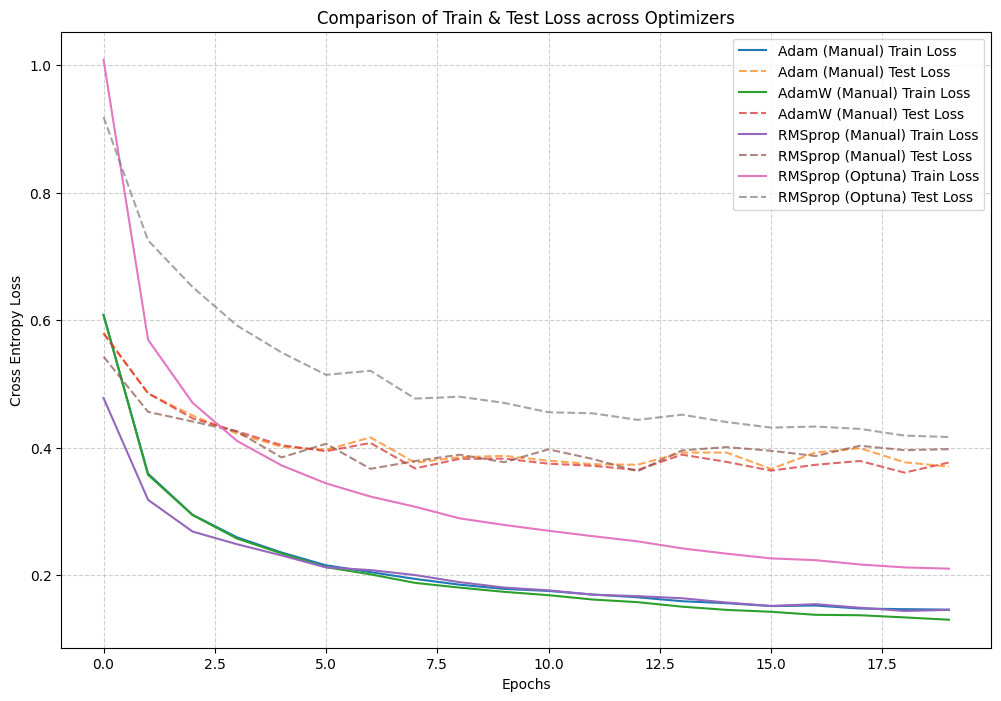

In [30]:
# Plot train and test loss curves over epochs
plt.figure(figsize=(12, 8))

# Iterate through all optimizers tested.
for label, metrics in plot_data.items():
    if metrics:
        epochs = range(len(metrics["train_losses"]))
        
        # Plot Training Loss (Solid line)
        plt.plot(
            epochs, 
            metrics["train_losses"], 
            linestyle='-', 
            label=f'{label} Train Loss'
        )
        
        # Plot Test Loss (Dashed line)
        plt.plot(
            epochs, 
            metrics["test_losses"], 
            linestyle='--', 
            alpha=0.7, # Slightly lighter to differentiate from training
            label=f'{label} Test Loss'
        )

plt.xlabel('Epochs')
plt.ylabel('Cross Entropy Loss')
plt.title('Comparison of Train & Test Loss across Optimizers')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

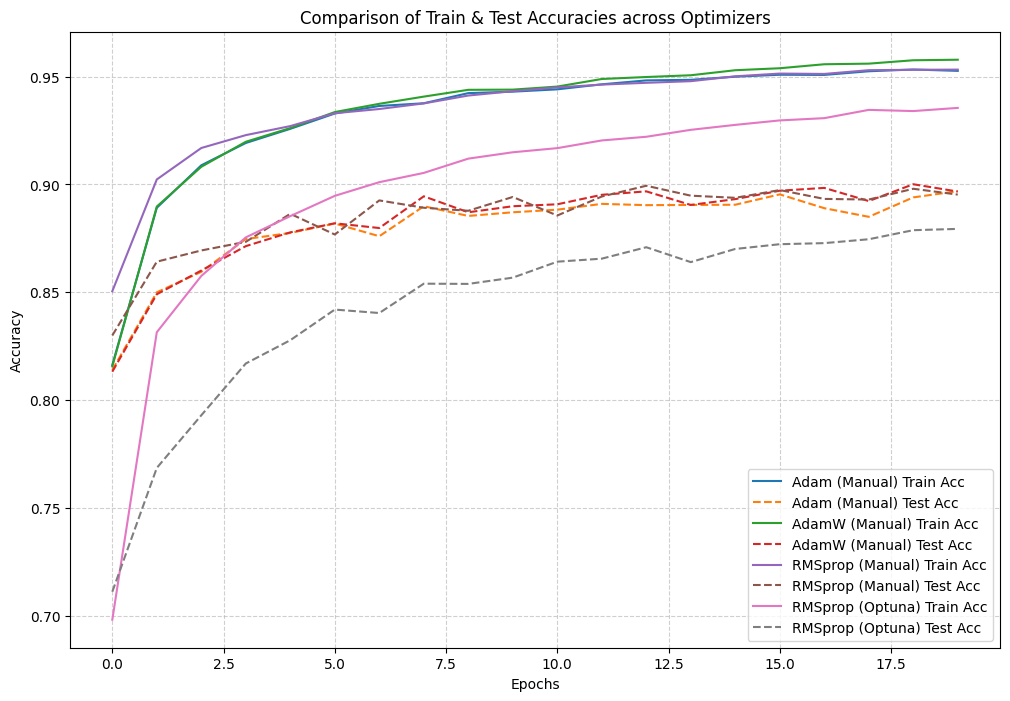

In [31]:
# Train and Test Accuracies over Epochs
plt.figure(figsize=(12, 8))

# All optimizers
for label, metrics in plot_data.items():
    if metrics:
        epochs = range(len(metrics["train_accuracies"]))
        
        plt.plot(epochs, metrics["train_accuracies"], linestyle='-', label=f'{label} Train Acc')
        plt.plot(epochs, metrics["test_accuracies"], linestyle='--', label=f'{label} Test Acc')

# Add info
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Comparison of Train & Test Accuracies across Optimizers')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

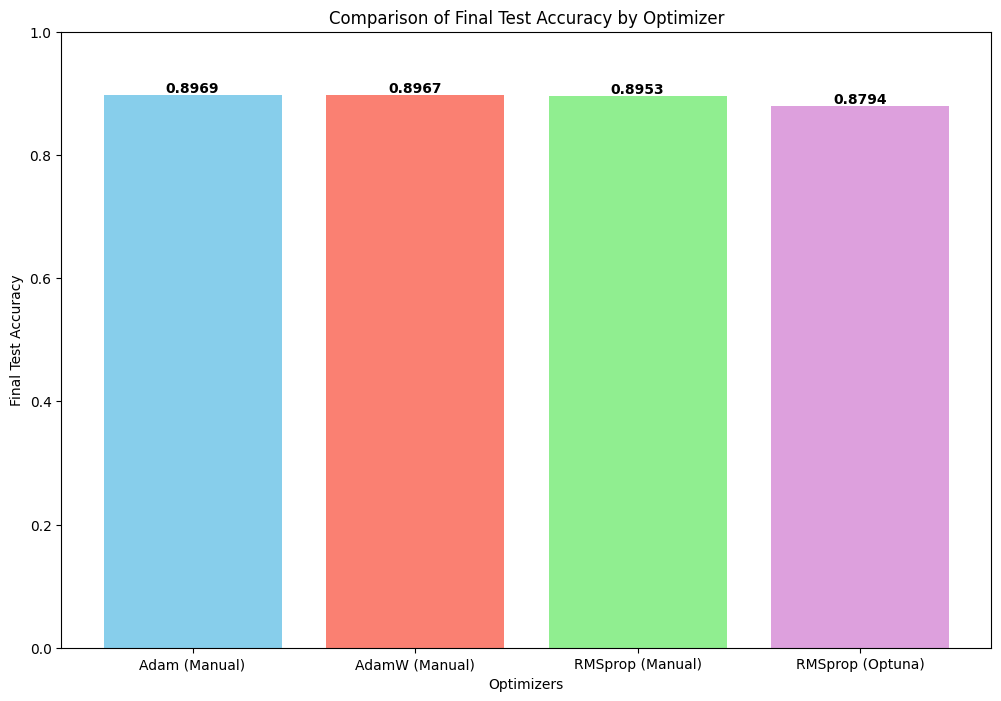

In [32]:
# Bar chart comparing final test accuracy across optimizers
labels = list(plot_data.keys())
final_test_accs = [plot_data[label]["test_accuracies"][-1] for label in labels]

plt.figure(figsize=(12, 8))
bars = plt.bar(labels, final_test_accs, color=['skyblue', 'salmon', 'lightgreen', 'plum'])

# Add numerical labels on top of the bars for clarity
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.4f}', 
             va='bottom', ha='center', fontweight='bold')

# Add info
plt.xlabel('Optimizers')
plt.ylabel('Final Test Accuracy')
plt.title('Comparison of Final Test Accuracy by Optimizer')
plt.ylim(0, 1.0)
plt.show()

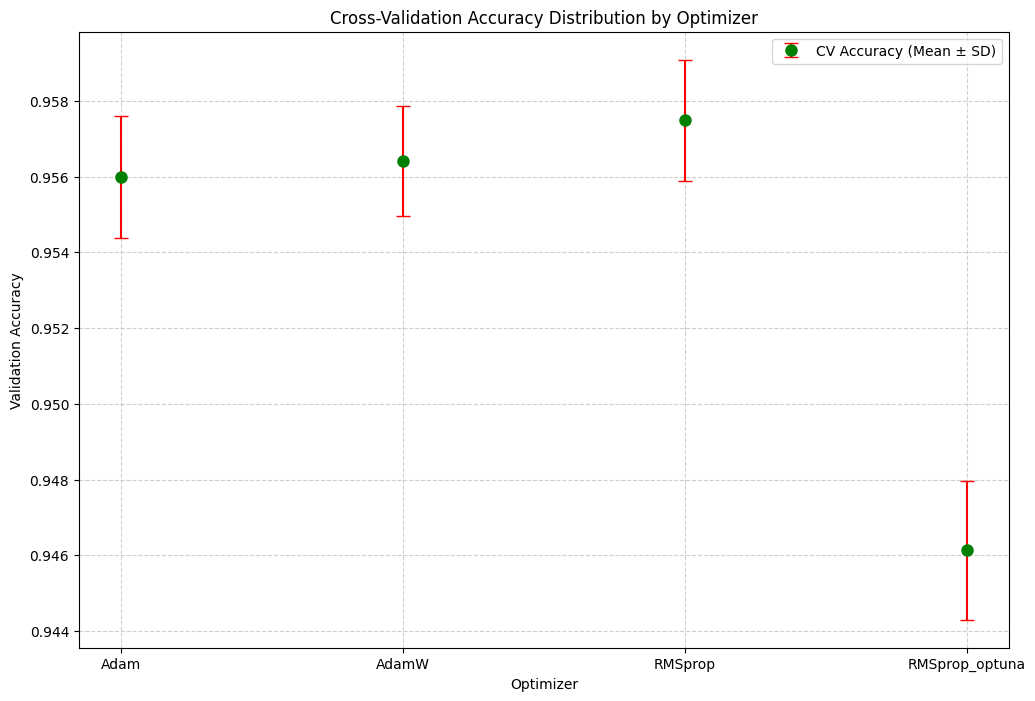

In [33]:
# Error plot for cross-validationa ccuracy distribution per optimizer
opt_names = list(results_storage.keys())
means = [results_storage[name]["best_data"][0] for name in opt_names]
stddevs = [results_storage[name]["best_data"][1] for name in opt_names]

# Define size
plt.figure(figsize=(12, 8))

# Plot the error bar
plt.errorbar(
    x=opt_names, 
    y=means, 
    yerr=stddevs, 
    fmt='o', 
    markersize=8, 
    capsize=5, 
    color='green', 
    ecolor='red', 
    label='CV Accuracy (Mean ± SD)'
)

# Add info
plt.title('Cross-Validation Accuracy Distribution by Optimizer')
plt.xlabel('Optimizer')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [34]:
# 6.2: Optional: learning-rate sensitivity plot showing validation accuracy vs. learning rate for each optimizer. 


In [35]:
# 6.3 Reproducibility
# Final Report TODO: Will add later.

# 7. Interpretation and Discussion 
### 7.1  Optimizer Analysis 
- Describe the convergence behaviour of each optimizer. Which converged fastest? Which was 
most stable? 
- Discuss  how  each  optimizer  responded  to  learning  rate  changes.  Was  any  optimizer 
particularly sensitive or robust? 
- Compare the generalization gap (train accuracy vs. test accuracy) across optimizers. What 
might explain the differences? 
 
### 7.2  Weight Decay and Regularization 
- Explain,  with  reference  to  your  results,  how  decoupled  weight  decay  in  AdamW  affects 
generalization compared with Adam. 
- If AdamW did not outperform Adam in your experiment, provide a hypothesis for why. 
 
### 7.3  Conclusion and Recommendation 
- State clearly which optimizer performed best on KMNIST and why. 
- Suggest when you would choose each optimizer in a real-world scenario, beyond this specific 
task. 
- Identify at least two limitations of your experimental design and suggest how future work could address them.

# Branch TODO 5
For each of the sections below, conduct analyses based solely on the optimizer chosen first. Ignore the comparisons for now; for instance, just describe the convergence behavior of the selected optimizer (e.g., RMSProp) on its own while including empirical values; these values will be helpful later as we synthesize the findings for the comparison.

### Adam — Convergence and Analysis

**Hyperparameter Search Strategy:**
A manual systematic approach was used. The learning rate was varied across two
orders of magnitude (0.0001 to 0.01) while keeping other parameters fixed.
The effect of weight_decay was also investigated across four configurations.

**Convergence behaviour:**
Adam converged steadily on the KMNIST dataset. The best configuration
(lr=0.001, weight_decay=1e-4) reached a mean validation accuracy of 95.61% across
5 folds, with each fold completing in approximately 3-5 minutes on GPU.

**Effect of learning rate:**
- Config 1 (lr=0.001, default): achieved 95.61% mean validation accuracy — best overall.
- Config 2 (lr=0.01): achieved 95.68% in cross-validation but showed a failure mode
  in final training due to the combined effect with weight_decay=1e-3 (see below).
- Config 3 (lr=0.0001): performed worst with 94.15%, starting at only ~58%
  training accuracy at Epoch 1 — insufficient to converge well in 20 epochs.

**Effect of weight_decay:**
- Config 1 (lr=0.001, weight_decay=1e-4): best stable configuration. A small decay
  had no measurable negative effect on convergence.
- Config 2 (lr=0.01, weight_decay=1e-3): showed a clear failure mode — training
  accuracy stagnated at ~83% throughout all 20 epochs. The combination of a high
  learning rate and aggressive weight decay prevented convergence.
- Config 4 (lr=0.001, weight_decay=1e-2): aggressive decay with standard lr also
  reduced performance compared to Config 1.

**Final training results (best configuration: lr=0.001, weight_decay=1e-4):**
- Best test accuracy: 89.91% (Epoch 16)
- Final train accuracy: 95.26%
- Generalization gap: ~5.35%, indicating moderate overfitting.

**Best configuration:** lr=0.001, weight_decay=1e-4, achieving 95.61% mean validation
accuracy across 5 folds and 89.91% on the held-out test set.



In [36]:
# 7.1 Optimizer Analysis (Single Focus)
# Add information about the convergence behavior of the single optimizer
# Add information about how the optimizer responded to learning rate changes
# Add information about the generalization gap within the single optimizer.


In [37]:
# 7.2 Weight Decay & Regularization (Not Applicable)


In [38]:
# 7.3 Conclusion & Recommendation
# Add information about when the optimizer might be chosen for a real-world scenario.
# Identify one limitation in the experimental design with respect to the optimizer
# Suggest how future work may address the limitation.
